# Model Improvement After Feedback (10/09)

We show the desired outcome (**L1** and **L2** products on the full time series) with the continuous integration setup.  

To reduce the willingness of the data, we add a local filter which consider as outlier an observation based on the local delta distribution.

We will only consider the **forecasted data**, since the retroactive gapfilled data are identical.  

---

## Improvements

The improvements are the following:  

- adding a local filter to reduce the data willingness
- Including a multiplicative factor to avoid unwanted behavior  
- Testing the three different smoothing options


In [1]:
#  nohup python -u  /home/francesco/data_scratch/swiss-ndvi-processing/demo/notebook/gif_fire_area.py>  /home/francesco/data_scratch/swiss-ndvi-processing/demo/output/log/fire_extraction.log 
# 2>/dev/null &

from IPython.display import IFrame, Image, display
import numpy as np
import math
import zarr
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import xarray as xr
import torch
import torch.nn as nn
import pandas as pd
from scipy.signal import savgol_filter
import gc
import imageio
from io import BytesIO
from functions import *

import geopandas as gpd
from rasterio import features
from affine import Affine
from shapely.geometry import Point

import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning, message="divide by zero encountered in divide")





This is the full gapfilled time serie with the smoothing using Savitzky Golay

In [2]:
# data loading and raster initialization
# ----- Config -----

# fitting and smoothing
# ----- seasonal cycle fitting -----
ds = xr.open_zarr("/home/francesco/data_scratch/swiss-ndvi-processing/sample_seasonal_cycle_parameter_preds.zarr")
ndvi = ds["ndvi"]
dates = ds["dates"]
params_lower = torch.tensor(ds["params_lower"].values)
params_upper = torch.tensor(ds["params_upper"].values)

# convert dates to doy
dates_pd = pd.to_datetime(dates)
df = pd.DataFrame({"date": dates_pd})
df_sorted = df.sort_values(by="date")
dates_sorted = df_sorted["date"].values
dates_pd_sorted = pd.to_datetime(dates_sorted)
doy = dates_pd_sorted.dayofyear.values
doy = torch.tensor(doy, dtype=torch.float32)
T_SCALE = 1.0 / 365.0
t = doy.unsqueeze(0).repeat(params_lower.shape[0], 1) * T_SCALE


lower = double_logistic_function(t[[0]], params_lower[[91]]).squeeze().cpu().numpy()
upper = double_logistic_function(t[[0]], params_upper[[91]]).squeeze().cpu().numpy()

median_iqr = upper - (upper - lower) / 2

param_iqr = 1.02
bottom_iqr = 0.2
upper_iqr = 0.8
window_length = 14
polyorder = 2

# area extracion

# ----- Config -----
zarr_path = "/data_2/scratch/sbiegel/processed/ndvi_dataset.zarr/ndvi"
mask_path = "/data_2/scratch/sbiegel/processed/forest_mask.npy"

z = zarr.open(zarr_path, mode="r")

# Raster info
height, width = 24542, 37728
left, bottom = 2474090.0, 1065110.0
px = 10.0
top = bottom + height * px

# ----- load polygon from KML -----
gdf = gpd.read_file("/home/francesco/data_scratch/swiss-ndvi-processing/demo/shapefiles/Bistch_area_extended.kml", driver="KML")
gdf = gdf.to_crs(epsg=2056)   # Swiss LV95
polygon = gdf.geometry.unary_union

# ----- raster info -----
height, width = 24542, 37728
left, bottom = 2474090.0, 1065110.0
px = 10.0
top = bottom + height * px

# ----- polygon bounds -> pixel window -----
x_min, y_min, x_max, y_max = polygon.bounds

col_min = int(math.floor((x_min - left) / px))
col_max = int(math.floor((x_max - left) / px))
row_min = int(math.floor((top - y_max) / px))
row_max = int(math.floor((top - y_min) / px))

# clip to raster extent
col_min = max(0, min(width - 1, col_min))
col_max = max(0, min(width - 1, col_max))
row_min = max(0, min(height - 1, row_min))
row_max = max(0, min(height - 1, row_max))

win_cols = col_max - col_min + 1
win_rows = row_max - row_min + 1
print(f"Window cols {col_min}..{col_max} ({win_cols}), rows {row_min}..{row_max} ({win_rows})")

# ----- load mask -----
mask = np.load(mask_path)
assert mask.shape == (height, width), f"Mask shape {mask.shape} != raster {(height, width)}"

mask_flat = mask.ravel(order="C")
masked_positions = np.flatnonzero(mask_flat)
n_masked = masked_positions.size
print(f"Mask has {n_masked} True pixels.")

# build index map from full array -> masked array
idx_map = np.full(mask_flat.shape[0], -1, dtype=np.int64)
idx_map[masked_positions] = np.arange(n_masked, dtype=np.int64)

# ----- compute pixel centers in window -----
rows = np.arange(row_min, row_max + 1, dtype=np.int64)
cols = np.arange(col_min, col_max + 1, dtype=np.int64)
rr, cc = np.meshgrid(rows, cols, indexing="ij")

xx = left + (cc + 0.5) * px
yy = top - (rr + 0.5) * px

# ----- rasterize polygon to mask instead of looping -----
transform = Affine(px, 0, left, 0, -px, top)
poly_mask = features.rasterize(
    [(polygon, 1)],
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype="uint8"
)

# extract only window
inside_mask = poly_mask[row_min:row_max+1, col_min:col_max+1].astype(bool)

# flatten to keep same workflow
inside = inside_mask.ravel()

# ----- flat indices -----
full_flat_idx = (rr * width + cc).ravel()

# keep only pixels inside polygon
poly_flat_idx = full_flat_idx[inside]

masked_idx_in_window = idx_map[poly_flat_idx]
is_masked = masked_idx_in_window >= 0
n_masked_in_window = is_masked.sum()
print(f"Pixels in window: {full_flat_idx.size}, masked pixels in polygon: {n_masked_in_window}")

if n_masked_in_window == 0:
    raise RuntimeError("No masked pixels in polygon!")

sel = masked_idx_in_window[is_masked].tolist()


# ----- open Zarr -----
N, T = z.shape
assert N == n_masked, f"Zarr first-dim {N} != mask True count {n_masked}"

# ----- plotting extent -----
extent = (
    left + col_min * px,
    left + (col_max + 1) * px,
    top - (row_max + 1) * px,
    top - row_min * px,
)


full_index = pd.date_range(min(dates_sorted), max(dates_sorted), freq="D")
full_index = full_index[full_index >= pd.Timestamp("2018-03-01")]

T = len(full_index)

# Limit to first timesteps
d_frames = min(3000, T)



/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/tmp/ipykernel_2611446/1774705593.py:52: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = gdf.geometry.unary_union


Window cols 16944..17065 (122), rows 17578..17731 (154)
Mask has 105715396 True pixels.
Pixels in window: 18788, masked pixels in polygon: 7543


In [3]:
# new zarr creation
# ----- open new zarr output -----
ndvi_chunk = np.empty((len(masked_idx_in_window[is_masked]), T), dtype=np.float32)
ndvi_chuck_smoothed = np.empty((len(masked_idx_in_window[is_masked]), T), dtype=np.float32)

Gapfilling pixel 262/7543
8
8
8
8
8


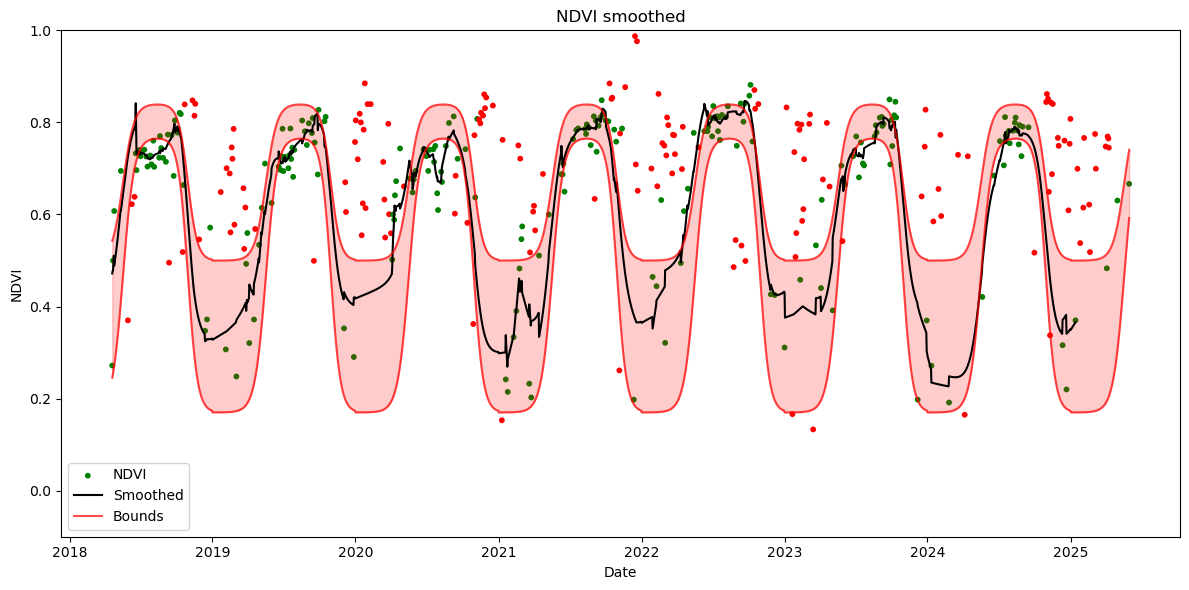

Gapfilling pixel 263/7543
8
8
8


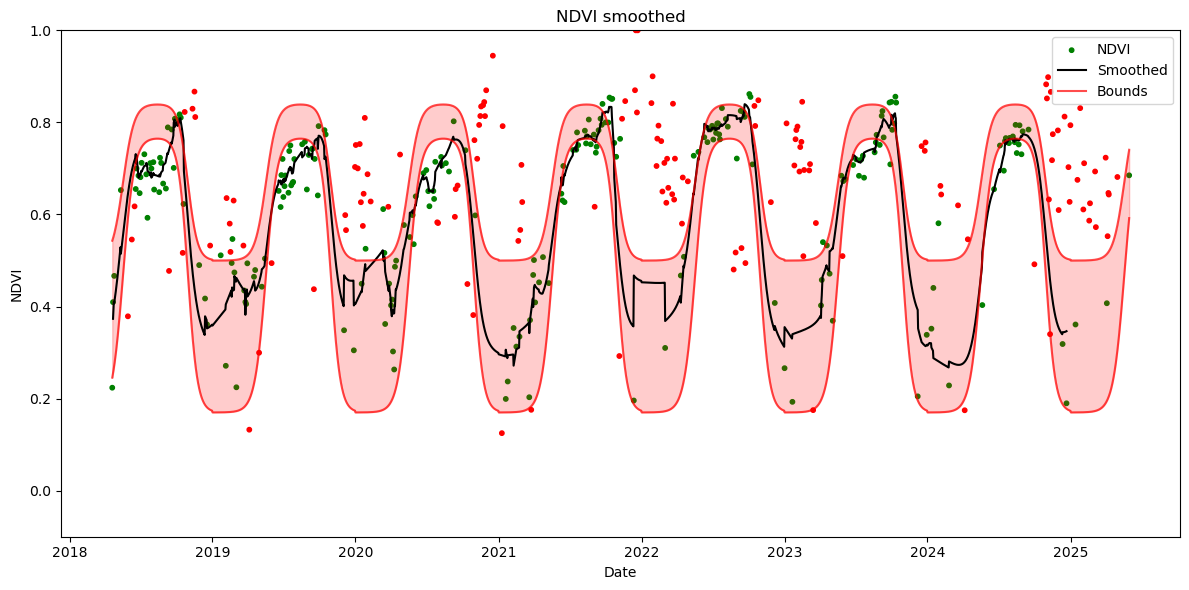

Gapfilling pixel 264/7543
8
8
8


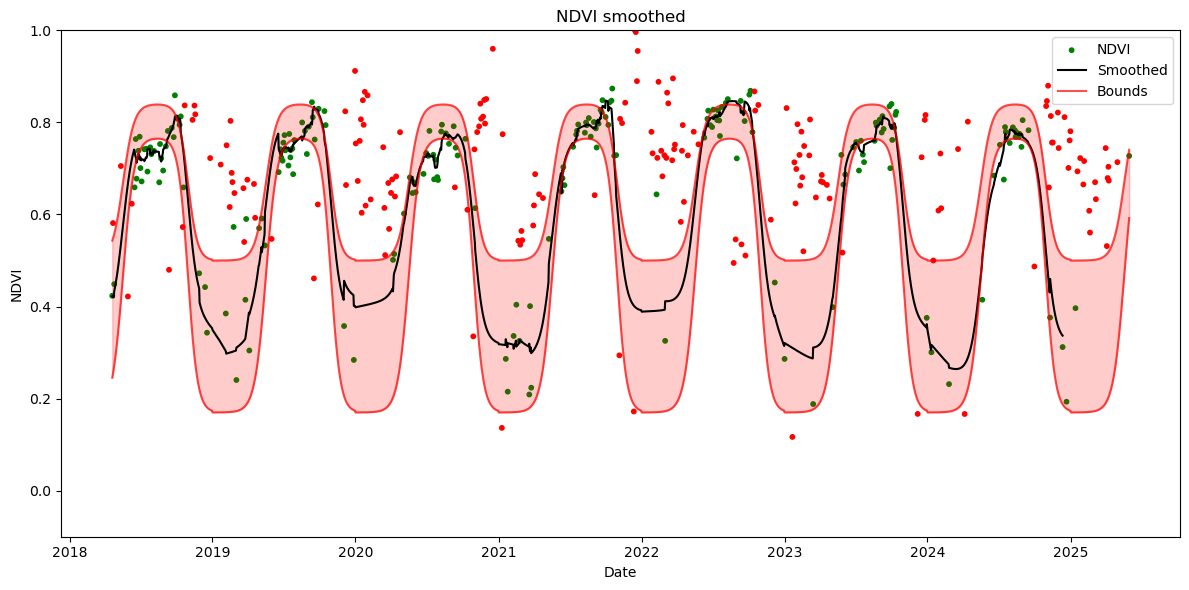

Gapfilling pixel 265/7543
4


ValueError: Lowess `frac` must be in the range [0,1]!

In [4]:
# ----- GAPFILLING LOOP -----
for i, pixel_sel in enumerate(sel):

    if i < 262:
        continue

    print(f"Gapfilling pixel {i}/{len(sel)}")

    ndvi_series = z[pixel_sel, :]   # raw time series

    # proper sorting
    df = pd.DataFrame({
        'date': dates_pd,
        'ndvi': ndvi_series
        })

    df_sorted = df.sort_values(by='date')

    ndvi_sorted = df_sorted['ndvi'].values

    
    ndvi_gapfilled, outlier_arr, q_hi, q_low, delta_diff, iqr_param, smoothed,valid_outlier, valid_idx, deltas = gapfill_ndvi(ndvi_sorted, lower, upper,forecasting=False,
                                            param_iqr=1.02,bottom_q=0.4,
                                            top_q=0.6,return_quantiles = True, weight_median = 0.5,smoothing_method = "savgol")


    y_delta_l , y_delta_h,r_delta_h, r_delta_l  = np.quantile(delta_diff, [0.2,0.8,0.9,0.05])
    y_iqr, r_iqr = np.quantile(iqr_param, [0.4, 0.8])


    # placeholders
    deltas = np.full(len(ndvi), np.nan)
    smoothed = np.full(len(ndvi), np.nan)

    # clean and normalize NDVI
    ndvi = ndvi_series.astype(float) / 10000.0
    ndvi = np.where((ndvi > 1) | (ndvi < 0), np.nan, ndvi)

    # make sure all arrays are 1-D
    df_starting = pd.DataFrame({
        "date": pd.to_datetime(dates_pd),
        "ndvi": ndvi.ravel()
    })

    # --- 2. Handle duplicate dates ---
    df_starting = (
        df_starting.groupby("date", as_index=False)
        .mean(numeric_only=True)   # average if duplicates exist
        .set_index("date")
    )

    # --- 3. Reindex to full daily series ---
    full_index = pd.date_range(df_starting.index.min(), df_starting.index.max(), freq="D")
    df = df_starting.reindex(full_index)

    # add forecast column for later use
    df["forecast"] = np.nan
    df["upper"] = np.nan
    df["lower"] = np.nan
    df["gapfilled"] = np.nan
    df["outlier"] = True
    df["delta_smoothed"] = np.nan
    df["deltas"] = np.nan
    df["idx"] = np.arange(len(df))
    df["deltas_L1"] = np.nan

    df.index.name = "date"

    # remove data veofre marh 2018
    df = df.loc[df.index >= pd.Timestamp("2018-03-01")]

    last_date = None
    last_potential_dates = []
    deltas_arr = []
    dates_delta_arr = []

    for date in df.index[df.index >= pd.Timestamp("2018-03-01")]:
        last_date, last_potential_date_arr, deltas_arr, dates_delta_arr = ndvi_continous_final(
            df=df,
            date=date,
            params_lower =  params_lower[[91]],
            params_upper =  params_upper[[91]],
            last_date=last_date,
            deltas_arr = deltas_arr,
            dates_delta_arr = dates_delta_arr,
            last_potential_dates = last_potential_dates,
            y_delta_l = y_delta_l, 
            y_delta_h = y_delta_h,
            r_delta_h = r_delta_h, 
            r_delta_l = r_delta_l,
            y_iqr= y_iqr, 
            r_iqr = r_iqr,
            tau = 45,
            smoothing_values = 7,
            frac= 1
        )

        # Select a date range if needed

    # Crop df_plot to that date
    df_plot = df[(df.index >= "2018-04-20") & (df.index <=  df[df["outlier"] == False].index.max())]

    fig, ax = plt.subplots(figsize=(12, 6))

    color_map = df_plot["outlier"].map({False: "green", True: "red"}).fillna("gray")

    ax.scatter(df_plot.index, df_plot["ndvi"], color=color_map, label='NDVI', s=10)

    # Forecast as black points
    ax.plot(df_plot.index, df_plot["delta_smoothed"] + 0.5 *(df_plot["upper"] + df_plot["lower"]), color='black', label='Smoothed')
    ax.plot(df_plot.index, df_plot["upper"], label="Bounds", color="red", alpha=0.7)
    ax.plot(df_plot.index, df_plot["lower"],  color="red", alpha=0.7)
    ax.fill_between(df_plot.index, df_plot["upper"], df_plot["lower"], alpha=0.2, color="red")

    ax.set_title("NDVI smoothed")
    ax.set_ylim(-0.1, 1.0)
    ax.set_xlabel("Date")
    ax.set_ylabel("NDVI")
    ax.legend()
    plt.tight_layout()
    plt.show()

    ndvi_chuck_smoothed[i, :] = df["delta_smoothed"] + 0.5 *(df["upper"] + df["lower"])
    ndvi_chunk[i,:] = df["ndvi"]


print("finished gapfilling")

In [5]:
df["delta_smoothed"]

date
2018-03-01   NaN
2018-03-02   NaN
2018-03-03   NaN
2018-03-04   NaN
2018-03-05   NaN
              ..
2025-05-27   NaN
2025-05-28   NaN
2025-05-29   NaN
2025-05-30   NaN
2025-05-31   NaN
Freq: D, Name: delta_smoothed, Length: 2649, dtype: float64